In [1]:
import torch

In [2]:

words = open('names.txt', 'r').read().splitlines()

In [3]:
chars = sorted(list(set(''.join([ w.strip() for w in  words]))))
chars = ['.'] + chars
stoi = { ch : i for i, ch in enumerate(chars) }
itos = {i: ch for ch, i in stoi.items()}


In [4]:
print(len(words))

min(len(w) for w in words)

32033


2

In [5]:
max(len(w) for w in words)

15

In [6]:


N = torch.zeros(27, 27, dtype = torch.int32)
for w in words:
    w = '.' + w + '.'
    for ch1, ch2 in zip(w, w[1:]):
        x1 = stoi[ch1]
        x2 = stoi[ch2]
        #print(ch1, ch2)
        N[x1, x2] += 1
    

p = N.float() / N.sum(dim= 1 , keepdim= True)
p[0]




tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

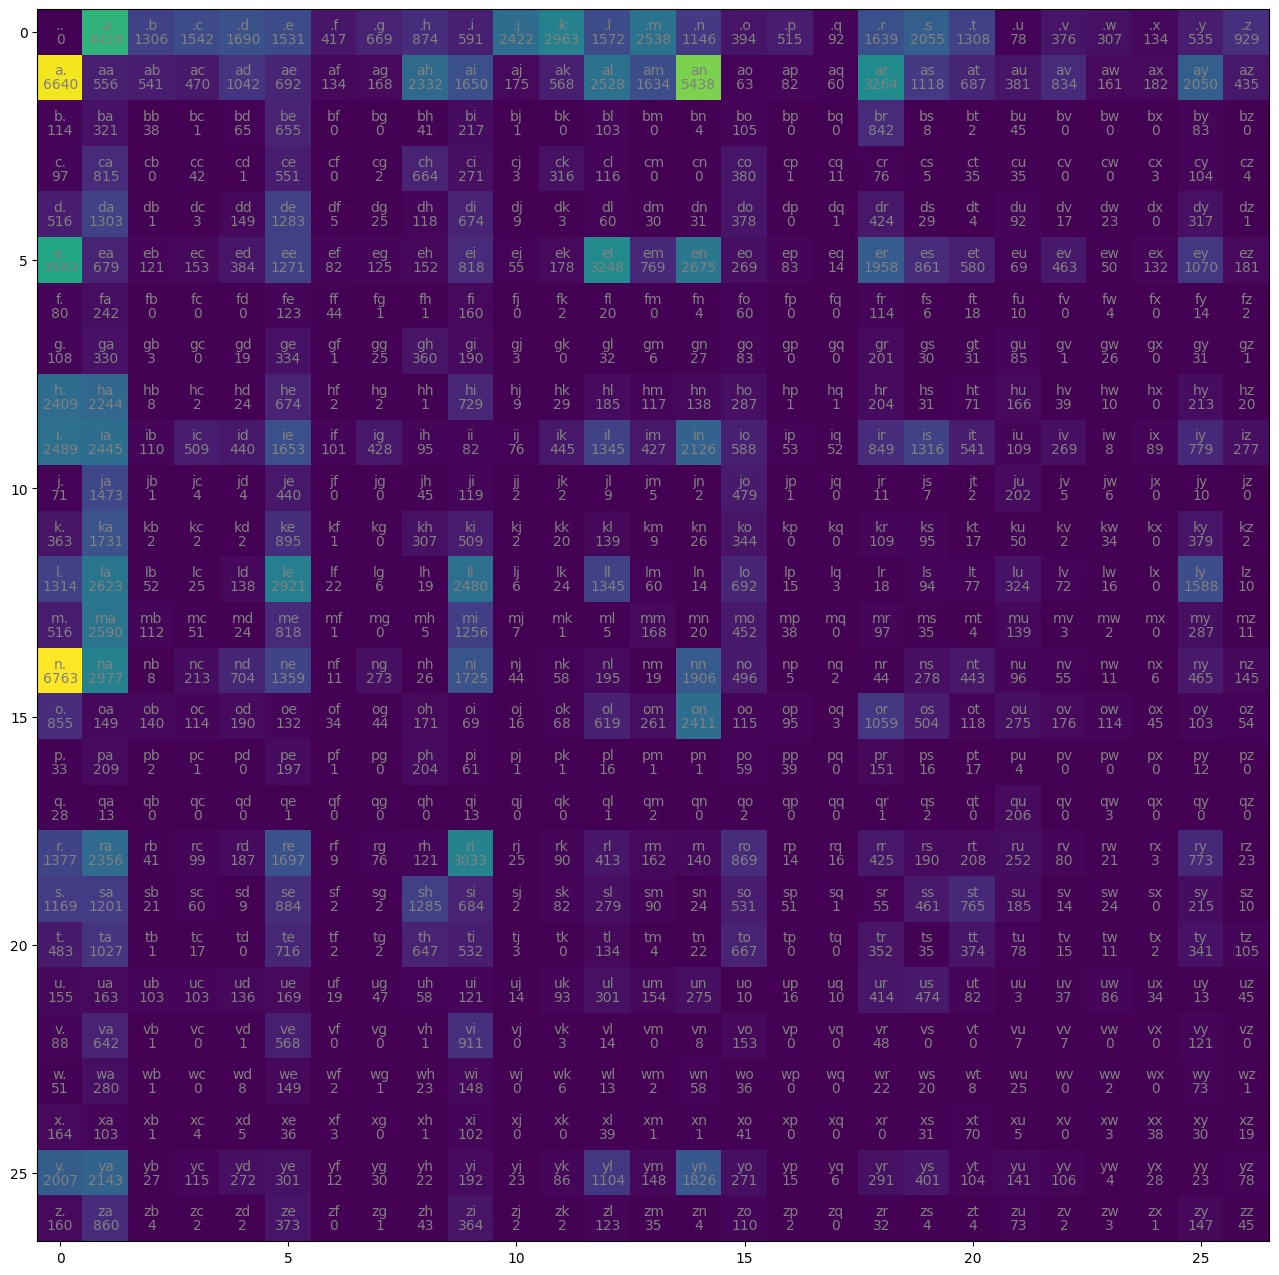

In [11]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N)
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = "grey")
        plt.text(j, i , N[i, j].item(), ha = "center", va = "top", color = "grey")

In [31]:
torch.__version__

'2.11.0+cpu'

In [28]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [36]:
g = torch.Generator().manual_seed(2147483647)

p = N.float() / N.sum(dim= 1 , keepdim=True)

for i in range(10):
    ix = 0
    out = []
    while True:
      ix = torch.multinomial(p[ix], num_samples= 1 , replacement=True, generator= g).item()
      out.append(ix)
      if ix == 0:
         break
    print( ''.join(itos[i] for i in out ) )

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [25]:

g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator = g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [19]:
torch.multinomial(p, num_samples= 100 , replacement=True, generator= g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])